# Example 3.9: Audio demo of stochastic time series

In this example, we generate four stationary stochastic time series from prescribed spectral densities. The time series are converted to audio.

The four processes are:

1. A narrow-banded process centered on C5 ($523.25$ Hz).
2. A two-band process centered on A4 ($440$ Hz) and A5 ($880$ Hz).
3. White noise.
4. Red noise with spectral content proportional to $1/\omega^2$.


## Define the four auto power spectral densities

Each spectrum is normalized so that its integral is one, so the four simulated processes have approximately equal variance.

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from IPython.display import Audio, display

duration = 10.0  # Duration [s]
sampling_frequency = 44100  # Audio sampling frequency [Hz]
N = int(duration*sampling_frequency)
t = np.arange(N)/sampling_frequency
f = np.fft.rfftfreq(N, d=1/sampling_frequency)
df = f[1] - f[0]

def narrow_peak(frequency, center_frequency, bandwidth):
    return np.exp(-0.5*((frequency-center_frequency)/bandwidth)**2)

# 1: A nearly tonal narrow band centered on C5
S_C = narrow_peak(f, center_frequency=523.25, bandwidth=0.6)

# 2: Two nearly tonal narrow bands separated by one octave
S_two_tones = (narrow_peak(f, center_frequency=440.00, bandwidth=0.6)
               + narrow_peak(f, center_frequency=880.00, bandwidth=0.6))

# 3 and 4: White and red noise
audible = (f >= 20.0) & (f <= 20000.0)
S_white = np.zeros_like(f)
S_white[audible] = 1.0

red_frequency_range = (f >= 20.0) & (f <= 4000.0)
S_red = np.zeros_like(f)
S_red[red_frequency_range] = 1.0/f[red_frequency_range]**2

spectra = [S_C, S_two_tones, S_white, S_red]
spectra = [S/np.trapezoid(S, f) for S in spectra]
S_C, S_two_tones, S_white, S_red = spectra

## Target spectra

The four normalized APSDs are shown below. A logarithmic frequency axis makes it possible to display the narrow peaks and the broadband spectra in the same figure.

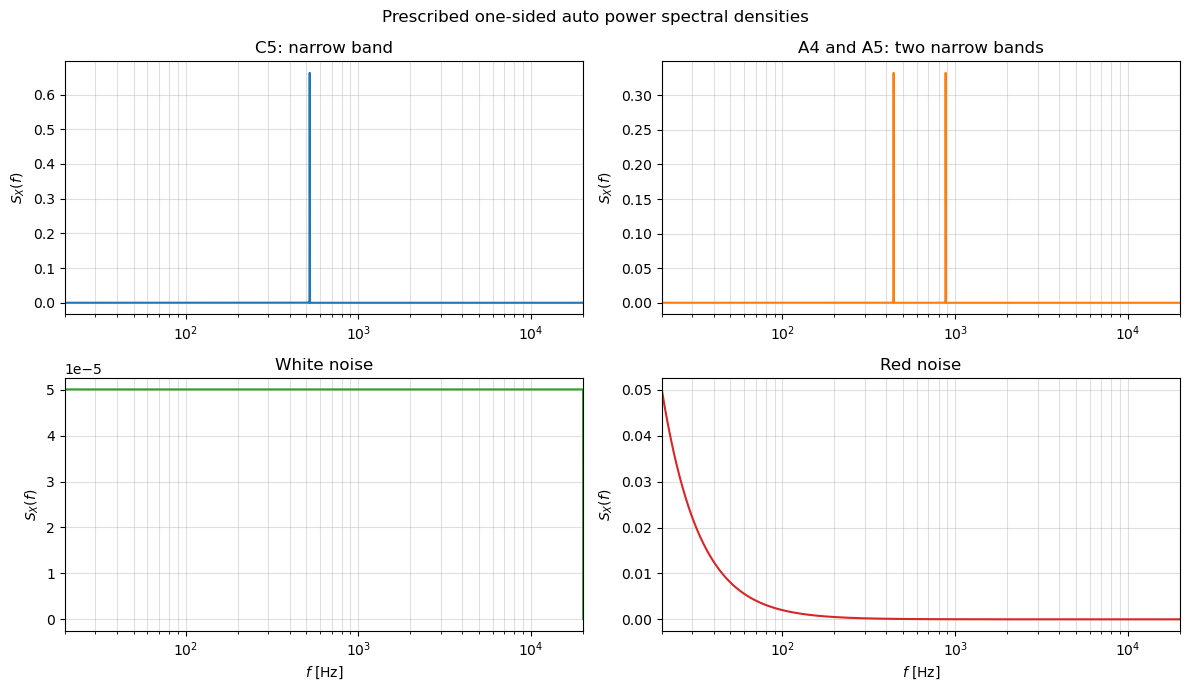

In [3]:
spectrum_names = ['C5: narrow band', 'A4 and A5: two narrow bands',
                  'White noise', 'Red noise']
spectrum_colors = ['C0', 'C1', 'C2', 'C3']

fig, axs = plt.subplots(2, 2, figsize=(12, 7))
for ax, S, name, color in zip(axs.flat, spectra, spectrum_names, spectrum_colors):
    ax.semilogx(f[1:], S[1:], color=color)
    ax.set_title(name)
    ax.set_xlim(20, 20000)
    ax.set_ylabel(r'$S_X(f)$')
    ax.grid(True, which='both', alpha=0.4)

axs[1, 0].set_xlabel(r'$f$ [Hz]')
axs[1, 1].set_xlabel(r'$f$ [Hz]')
fig.suptitle('Prescribed one-sided auto power spectral densities')
plt.tight_layout()

## IFFT-based simulation

We use the IFFT-based simulation method from Example 3.7. For frequency spacing $\Delta f$, the amplitude associated with the one-sided APSD at frequency $f_k$ is

$$ A_k=\sqrt{2S_X(f_k)\Delta f}. $$

Independent phase angles $\phi_k$ are uniformly distributed between $0$ and $2\pi$. The real time series can then be written as

$$ x(t)=\sum_k A_k\cos(2\pi f_k t+\phi_k). $$

This cosine sum is evaluated efficiently using `numpy.fft.irfft`. The scaling of the complex coefficients below makes the IFFT result equal to the cosine-sum expression.

In [4]:
def simulate_from_apsd(S, df, N):
    # Random phases make a new realization every time the cell is executed
    phi = 2*np.pi*np.random.rand(S.size)
    amplitude = np.sqrt(2*S*df)

    # irfft contributes 2*abs(c[k])/N for each positive-frequency bin
    c = N/2*amplitude*np.exp(1j*phi)
    c[0] = 0.0
    c[-1] = 0.0
    return np.fft.irfft(c, n=N)

x_C = simulate_from_apsd(S_C, df, N)
x_two_tones = simulate_from_apsd(S_two_tones, df, N)
x_white = simulate_from_apsd(S_white, df, N)
x_red = simulate_from_apsd(S_red, df, N)

time_series = [x_C, x_two_tones, x_white, x_red]

## Simulated time series

All realizations are 10 seconds long. Only the first 50 ms are displayed so that their rapid oscillations remain visible. The narrow-banded processes have a recognizable oscillatory structure, whereas the white- and red-noise processes are more irregular.

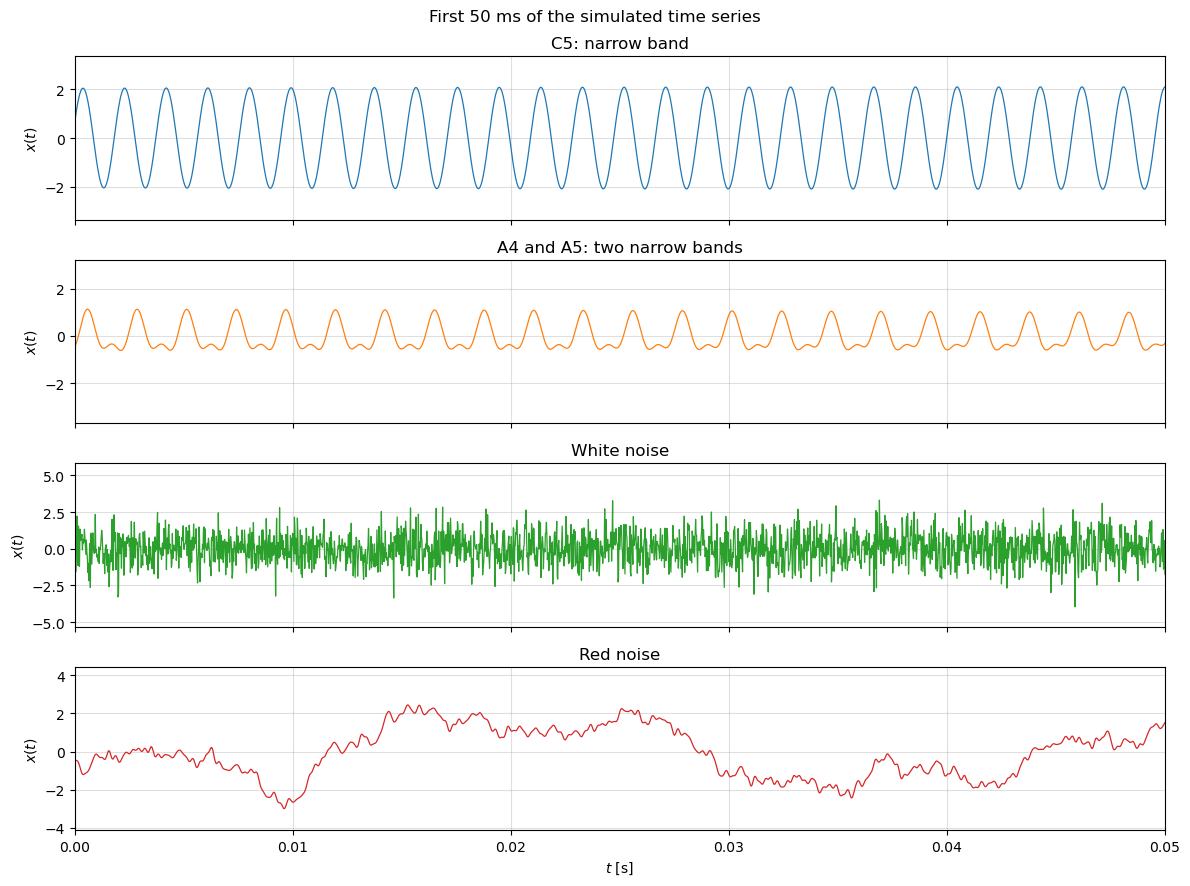

In [5]:
fig, axs = plt.subplots(4, 1, figsize=(12, 9), sharex=True)
for ax, x, name, color in zip(axs, time_series, spectrum_names, spectrum_colors):
    ax.plot(t, x, color=color, linewidth=0.9)
    ax.set_title(name)
    ax.set_ylabel(r'$x(t)$')
    ax.set_xlim(0, 0.05)
    ax.grid(True, alpha=0.4)

axs[-1].set_xlabel(r'$t$ [s]')
fig.suptitle('First 50 ms of the simulated time series')
plt.tight_layout()

## Listen to the realizations

Each player contains one 10-second realization. Play one at a time to compare how the prescribed APSD changes the sound. The signals are normalized for safe and comparable playback volume.

In [6]:
def play_audio(x, sampling_frequency):
    normalized_audio = 0.8*x/np.max(np.abs(x))
    display(Audio(normalized_audio, rate=sampling_frequency, normalize=False))

### 1. Narrow-banded process: C5

In [7]:
play_audio(x_C, sampling_frequency)

### 2. Two narrow bands: A4 and A5

In [8]:
play_audio(x_two_tones, sampling_frequency)

### 3. White noise

In [9]:
play_audio(x_white, sampling_frequency)

### 4. Red noise

In [10]:
play_audio(x_red, sampling_frequency)

## Observations

The narrow band around C5 sounds approximately like a single note whose amplitude varies slowly. Combining the A4 and A5 bands produces two clearly separated pitches one octave apart. White noise sounds bright because every frequency interval contains equal power. Red noise sounds much deeper because its power decreases in proportion to $1/f^2$, strongly concentrating the variance at low frequencies. Rerun the IFFT simulation cell to generate four new realizations with the same APSDs.